# A Machine Learning Approach to Predicting GDP Growth Using World Bank Development Indicators

**Student:** Muhammad Wasal Imtiaz (24077342)  
**Module:** 7PAM2002 Data Science Project  
**University of Hertfordshire — MSc Data Science**

---

## Research Questions
1. Which machine learning models best predict GDP growth using socio-economic and development indicators from the World Bank Open Data platform?
2. How do linear and non-linear machine learning models differ in predictive performance and generalisation when forecasting GDP growth across countries and time periods?
3. Which socio-economic indicators contribute most to GDP growth prediction, and how consistent are these feature importance patterns across different models?

## Indicators Used
| Indicator | Code | Role |
|---|---|---|
| GDP growth (annual %) | NY.GDP.MKTP.KD.ZG | **Target** |
| Inflation, consumer prices (annual %) | FP.CPI.TOTL.ZG | Macroeconomic stability |
| Unemployment (% of labour force) | SL.UEM.TOTL.ZS | Labour market |
| Internet users (% of population) | IT.NET.USER.ZS | Technology adoption |
| Population growth (annual %) | SP.POP.GROW | Demographics |
| Education expenditure (% of GDP) | SE.XPD.TOTL.GD.ZS | Human capital |
| Energy use (kg oil eq. per capita) | EG.USE.PCAP.KG.OE | Economic activity |

## Models
1. **Ridge Regression** (linear baseline)
2. **Random Forest Regressor** (non-linear, ensemble)
3. **Gradient Boosting Regressor** (optimised, ensemble)

---
## 1. Setup & Data Loading

In [1]:

# Mount Google Drive (Colab only)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# FILE PATHS — edit BASE if your files are in a subfolder
# ============================================================
BASE = "/content/drive/MyDrive/"

PATHS = {
    "GDP_Growth":      BASE + "API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_26.csv",
    "Inflation":       BASE + "API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_32.csv",
    "Unemployment":    BASE + "API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_44.csv",
    "Internet_Users":  BASE + "API_IT.NET.USER.ZS_DS2_en_csv_v2_1228.csv",
    "Pop_Growth":      BASE + "API_SP.POP.GROW_DS2_en_csv_v2_322.csv",
    "Education_Exp":   BASE + "API_SE.XPD.TOTL.GD.ZS_DS2_en_csv_v2_236.csv",
    "Energy_Use":      BASE + "API_EG.USE.PCAP.KG.OE_DS2_en_csv_v2_2093.csv",
}

import os
for name, path in PATHS.items():
    print(f"{name:20s} -> exists: {os.path.exists(path)}")

GDP_Growth           -> exists: True
Inflation            -> exists: True
Unemployment         -> exists: True
Internet_Users       -> exists: True
Pop_Growth           -> exists: True
Education_Exp        -> exists: True
Energy_Use           -> exists: True


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', 20)
print("All imports successful.")

All imports successful.


In [4]:
# ============================================================
# HELPER: Load & reshape a World Bank indicator CSV (wide -> long)
# ============================================================
def load_worldbank_indicator(csv_path: str, value_name: str) -> pd.DataFrame:
    """Read a World Bank CSV (4 header rows), drop metadata cols, reshape wide->long."""
    df = pd.read_csv(csv_path, skiprows=4)
    df = df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 69"], errors="ignore")
    df_long = df.melt(
        id_vars=["Country Name", "Country Code"],
        var_name="Year",
        value_name=value_name
    )
    df_long["Year"] = pd.to_numeric(df_long["Year"], errors="coerce")
    return df_long

# Load all 7 indicators
datasets = {}
for name, path in PATHS.items():
    datasets[name] = load_worldbank_indicator(path, name)
    print(f"Loaded {name}: {datasets[name].shape}")

Loaded GDP_Growth: (17290, 4)
Loaded Inflation: (17290, 4)
Loaded Unemployment: (17290, 4)
Loaded Internet_Users: (17290, 4)
Loaded Pop_Growth: (17290, 4)
Loaded Education_Exp: (17290, 4)
Loaded Energy_Use: (17290, 4)


In [5]:
# ============================================================
# MERGE all indicators into one panel dataset (Country x Year)
# ============================================================
keys = ["Country Name", "Country Code", "Year"]

# Start with GDP (target)
indicator_names = list(PATHS.keys())
data = datasets[indicator_names[0]].copy()

# Merge remaining indicators
for name in indicator_names[1:]:
    data = data.merge(datasets[name], on=keys, how="inner")

print(f"Raw merged dataset: {data.shape}")
print(f"Year range: {data['Year'].min():.0f} — {data['Year'].max():.0f}")
data.head()

Raw merged dataset: (17290, 10)
Year range: 1960 — 2024


,Country Name,Country Code,Year,GDP_Growth,Inflation,Unemployment,Internet_Users,Pop_Growth,Education_Exp,Energy_Use
0,Aruba,ABW,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploratory Data Analysis (EDA)

In [6]:
# ============================================================
# 2.1  Dataset overview
# ============================================================
print("Shape:", data.shape)
print("\nColumn types:")
print(data.dtypes)
print("\nBasic statistics (numeric):")
data.describe()

Shape: (17290, 10)

Column types:
Country Name       object
Country Code       object
Year                int64
GDP_Growth        float64
Inflation         float64
Unemployment      float64
Internet_Users    float64
Pop_Growth        float64
Education_Exp     float64
Energy_Use        float64
dtype: object

Basic statistics (numeric):


,Year,GDP_Growth,Inflation,Unemployment,Internet_Users,Pop_Growth,Education_Exp,Energy_Use
count,17290.000000,14133.000000,11295.000000,7981.000000,6738.000000,16928.000000,6378.000000,6569.000000
mean,1992.000000,3.672496,19.552575,7.809397,31.621091,1.732333,4.242956,2170.462245
std,18.762206,6.214758,284.790842,5.551420,31.790425,1.675854,2.013105,2645.911285
min,1960.000000,-64.047107,-17.640424,0.100000,0.000000,-27.470786,0.000000,0.000000
25%,1976.000000,1.414118,2.403127,4.057000,2.200967,0.727127,3.072027,509.245127
50%,1992.000000,3.800000,4.866320,6.306449,20.075650,1.702535,4.073984,1180.710719
75%,2008.000000,6.096139,9.619435,10.032037,59.218450,2.615780,5.119275,2770.359250
max,2024.000000,149.972963,23773.131774,38.800000,100.000000,21.700343,66.900307,21557.475076


                Missing  % Missing
GDP_Growth         3157       18.3
Inflation          5995       34.7
Unemployment       9309       53.8
Internet_Users    10552       61.0
Pop_Growth          362        2.1
Education_Exp     10912       63.1
Energy_Use        10721       62.0


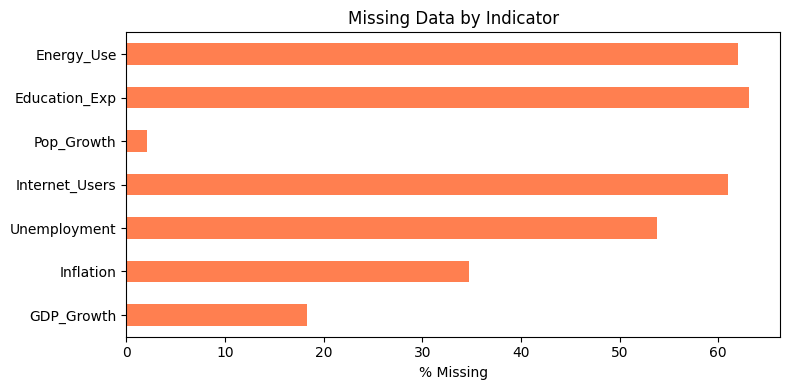

In [7]:
# ============================================================
# 2.2  Missing value analysis
# ============================================================
numeric_cols = ["GDP_Growth", "Inflation", "Unemployment", "Internet_Users",
                "Pop_Growth", "Education_Exp", "Energy_Use"]

missing = data[numeric_cols].isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)

missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
print(missing_df)

# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Indicator')
plt.tight_layout()
plt.show()

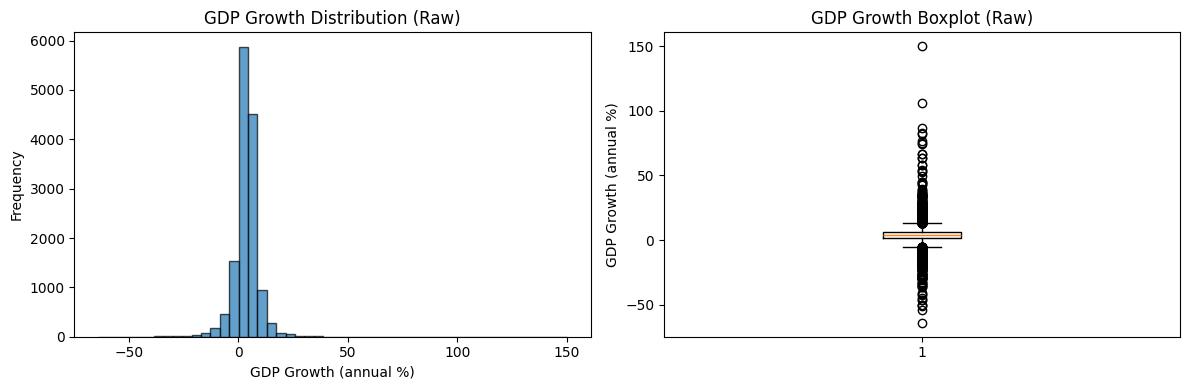

Mean:   3.67%
Median: 3.80%
Std:    6.21%
Min:    -64.05%
Max:    149.97%


In [8]:
# ============================================================
# 2.3  GDP Growth distribution (before cleaning)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(data["GDP_Growth"].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("GDP Growth (annual %)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("GDP Growth Distribution (Raw)")

# Boxplot
axes[1].boxplot(data["GDP_Growth"].dropna(), vert=True)
axes[1].set_ylabel("GDP Growth (annual %)")
axes[1].set_title("GDP Growth Boxplot (Raw)")

plt.tight_layout()
plt.show()

print(f"Mean:   {data['GDP_Growth'].mean():.2f}%")
print(f"Median: {data['GDP_Growth'].median():.2f}%")
print(f"Std:    {data['GDP_Growth'].std():.2f}%")
print(f"Min:    {data['GDP_Growth'].min():.2f}%")
print(f"Max:    {data['GDP_Growth'].max():.2f}%")

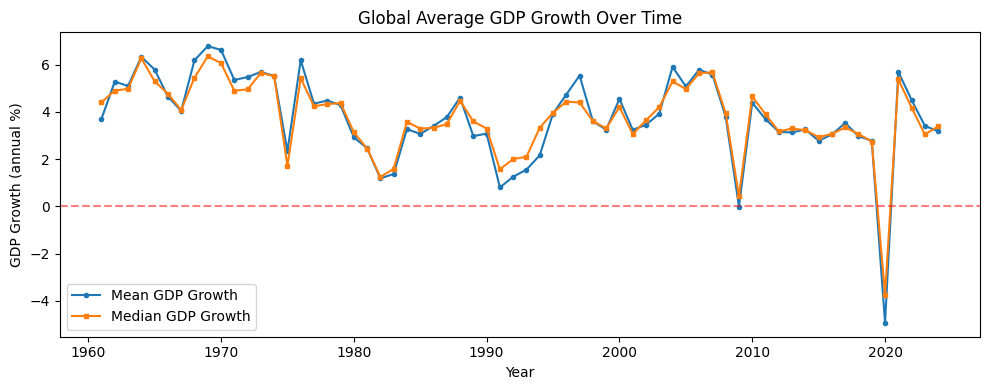

In [9]:
# ============================================================
# 2.4  Global GDP growth trend over time
# ============================================================
yearly_gdp = data.groupby("Year")["GDP_Growth"].agg(["mean", "median"]).dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_gdp.index, yearly_gdp["mean"], marker='o', markersize=3, label="Mean GDP Growth")
ax.plot(yearly_gdp.index, yearly_gdp["median"], marker='s', markersize=3, label="Median GDP Growth")
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (annual %)")
ax.set_title("Global Average GDP Growth Over Time")
ax.legend()
plt.tight_layout()
plt.show()

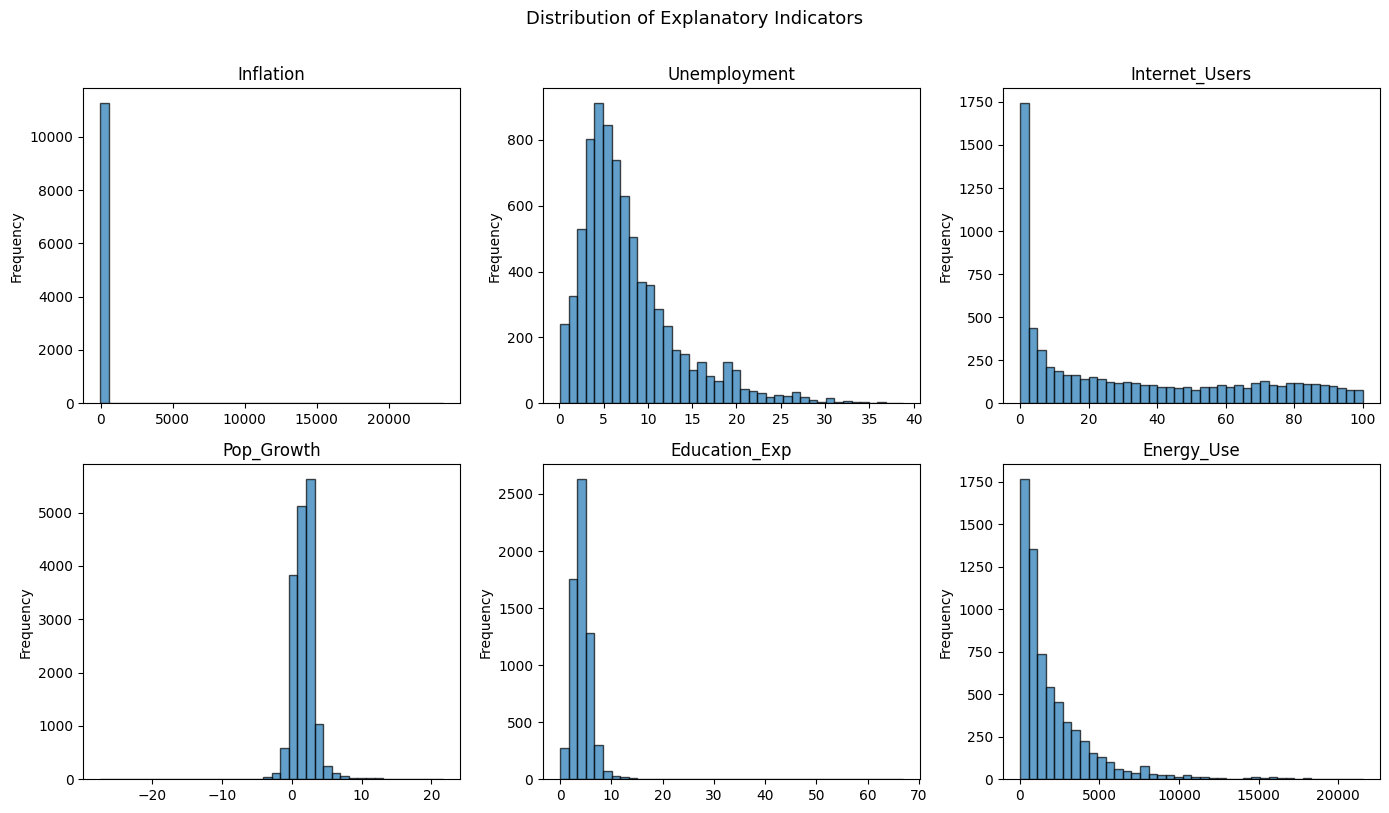

In [10]:
# ============================================================
# 2.5  Pairwise distributions of all indicators
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
feature_cols = ["Inflation", "Unemployment", "Internet_Users",
                "Pop_Growth", "Education_Exp", "Energy_Use"]

for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    vals = data[col].dropna()
    ax.hist(vals, bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distribution of Explanatory Indicators", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

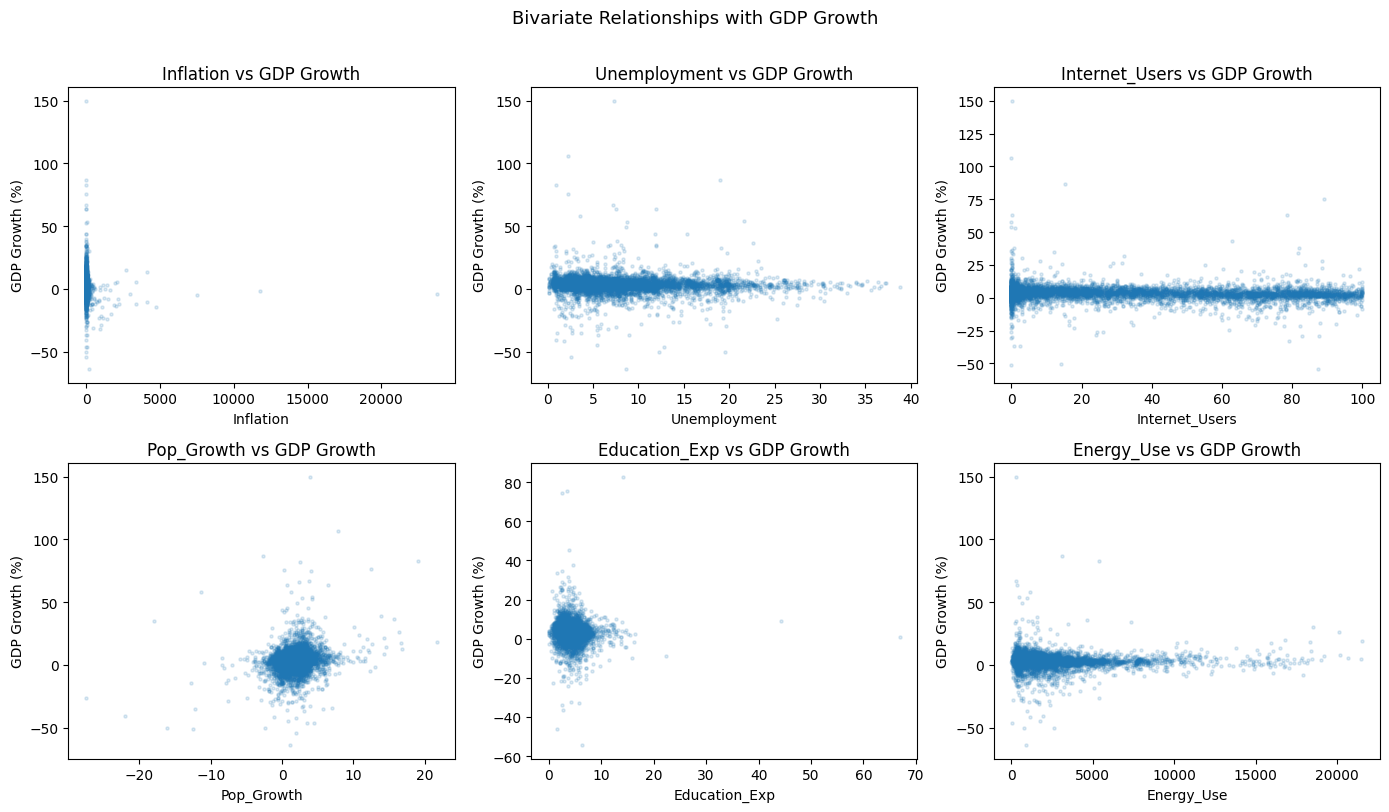

In [11]:
# ============================================================
# 2.6  Scatter plots: each indicator vs GDP Growth
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(feature_cols):
    ax = axes[i // 3, i % 3]
    subset = data[[col, "GDP_Growth"]].dropna()
    ax.scatter(subset[col], subset["GDP_Growth"], alpha=0.15, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel("GDP Growth (%)")
    ax.set_title(f"{col} vs GDP Growth")

plt.suptitle("Bivariate Relationships with GDP Growth", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

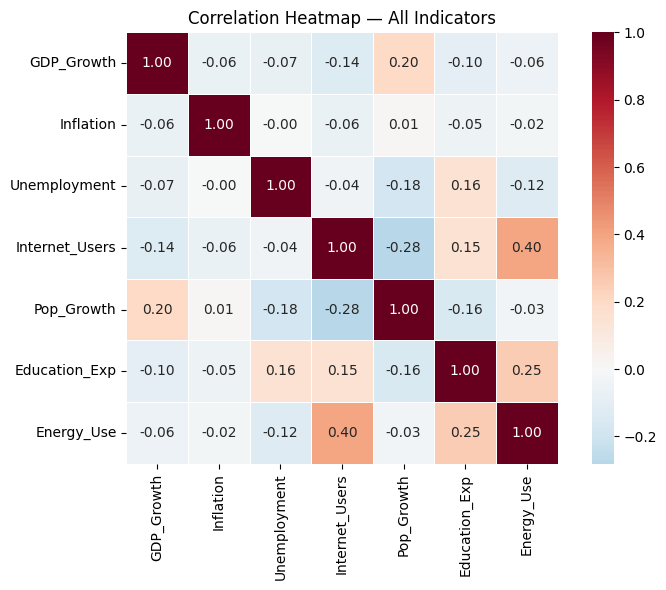

In [12]:
# ============================================================
# 2.7  Correlation heatmap (raw data)
# ============================================================
corr_cols = ["GDP_Growth"] + feature_cols
corr_matrix = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — All Indicators")
plt.tight_layout()
plt.show()